# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [4]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [5]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [6]:
type(registros)

list

In [7]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [8]:
dados = pd.DataFrame(registros)

In [9]:
dados.head(5)

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [10]:
print(f"{dados.shape[0]} linhas e {dados.shape[1]} colunas ")

336 linhas e 11 colunas 


In [11]:
print(dados.columns)

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')


In [12]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [13]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


> data/hora = dat_referencia

> área de carga =  cod_areacarga

> valor de carga = val_cargaglobal


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [14]:
# 1. Renomeando os atributos
dados_renomeados = dados.rename(
    columns={
        "cod_areacarga": "area_carga",
        "din_referenciautc": "data_hora_utc",
        "dat_referencia": "data_referencia",
        "val_cargaglobal": "carga_global_mw",
        "val_cargasupervisionada": "carga_supervisionada_mw",
        "val_carganaosupervisionada": "carga_nao_supervisionada_mw",
        "val_cargammgd": "carga_mmgd_mw",
    }
)

In [15]:
# 2. Criando um novo DataFrame com apenas os atributos necessários
atributos_relevantes = [
    "area_carga",
    "data_hora_utc",
    "data_referencia",
    "carga_global_mw",
    "carga_supervisionada_mw",
    "carga_nao_supervisionada_mw",
    "carga_mmgd_mw",
]

df_carga = dados_renomeados[atributos_relevantes].copy()

In [16]:
# 3 e 4. Verificação de valores ausentes em cada atributo relevante
valores_ausentes = df_carga.isna().sum()
print("--- Quantidade de valores ausentes por coluna ---")
print(valores_ausentes)

--- Quantidade de valores ausentes por coluna ---
area_carga                     0
data_hora_utc                  0
data_referencia                0
carga_global_mw                0
carga_supervisionada_mw        0
carga_nao_supervisionada_mw    0
carga_mmgd_mw                  0
dtype: int64


In [17]:
# 5. Tratamento e conversão dos tipos de dados
df_carga["carga_global_mw"] = pd.to_numeric(
    df_carga["carga_global_mw"], errors="coerce"
)

In [18]:
# 6. Conversão do atributo de data/hora de texto (object) para datetime
df_carga["data_hora_utc"] = pd.to_datetime(df_carga["data_hora_utc"])

In [19]:
print("DataFrame Tratado")
df_carga.info()

DataFrame Tratado
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   area_carga                   336 non-null    object             
 1   data_hora_utc                336 non-null    datetime64[ns, UTC]
 2   data_referencia              336 non-null    object             
 3   carga_global_mw              336 non-null    float64            
 4   carga_supervisionada_mw      336 non-null    float64            
 5   carga_nao_supervisionada_mw  336 non-null    float64            
 6   carga_mmgd_mw                336 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(4), object(2)
memory usage: 18.5+ KB


In [20]:
df_carga.head()

,area_carga,data_hora_utc,data_referencia,carga_global_mw,carga_supervisionada_mw,carga_nao_supervisionada_mw,carga_mmgd_mw
0,SP,2025-08-01 03:30:00+00:00,2025-08-01,15913.618,14421.112,1471.3759,21.13
1,SP,2025-08-01 04:00:00+00:00,2025-08-01,15251.414,13758.101,1472.1840,21.13
2,SP,2025-08-01 04:30:00+00:00,2025-08-01,14606.733,13112.602,1473.0022,21.13
3,SP,2025-08-01 05:00:00+00:00,2025-08-01,14182.290,12687.433,1473.7275,21.13
4,SP,2025-08-01 05:30:00+00:00,2025-08-01,13838.488,12342.648,1474.7096,21.13


> ### Decisões de Tratamento e Organização dos Dados
>
>
>  **Seleção e Renomeação de Atributos:**
> * Selecionamos apenas os atributos essenciais para a análise de carga ("area_carga", "data_hora_utc", "data_referencia", "carga_global_mw", "carga_supervisionada_mw", "carga_nao_supervisionada_mw", "carga_mmgd_mw").
> * Renomeamos os nomes originais para algo mais simples
>
>
>  **Tratamento de Valores Ausentes:**
> * Usamos os métodos ".isna().sum()", confirmando que **não existem valores nulos ou ausentes**
>
>
>  **Tipos de Dados e Formatação:**
> * **Carga Elétrica:** A variável principal ("carga_global_mw") e demais componentes de carga já se encontram originalmente no formato numérico **float64**. Aplicamos "pd.to_numeric" só pra ter certeza que está certo
>
>
> * **Data e Hora:** A coluna "din_referenciautc", que estava representada originalmente como texto/string ("object"), foi convertida para o formato nativo **datetime** utilizando "pd.to_datetime". Assim esse elemento terá as características de um horário mesmo.
>
>
>
>
>
>

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [21]:
# Desenvolva aqui o desafio 3

carga_minima = df_carga['carga_global_mw'].min()
carga_maxima = df_carga['carga_global_mw'].max()
carga_media = df_carga['carga_global_mw'].mean()
mediana = df_carga['carga_global_mw'].median()
amplitude = carga_maxima - carga_minima
quantidade_medicoes = len(df_carga)

print(f"Carga Mínima: {carga_minima:.2f} MW")
print(f"Carga Máxima: {carga_maxima:.2f} MW")
print(f"Carga Média: {carga_media:.2f} MW")
print(f"Mediana: {mediana:.2f} MW")
print(f"Amplitude (Máximo - Mínimo): {amplitude:.2f} MW")
print(f"Quantidade Total de Medições: {quantidade_medicoes}")




Carga Mínima: 12139.25 MW
Carga Máxima: 23185.31 MW
Carga Média: 17870.83 MW
Mediana: 18199.13 MW
Amplitude (Máximo - Mínimo): 11046.06 MW
Quantidade Total de Medições: 336


#Justificativa


In [22]:
print(f"""
O valor máximo ({carga_maxima:.2f} MW) está {carga_maxima - carga_media:.2f} MW acima da média
({carga_media:.2f} MW), uma diferença expressiva frente à amplitude total ({amplitude:.2f} MW).
Isso indica que o máximo é um pico pontual, não representativo do comportamento típico da carga,
que se aproxima mais da mediana ({mediana:.2f} MW)
"""
)


O valor máximo (23185.31 MW) está 5314.48 MW acima da média
(17870.83 MW), uma diferença expressiva frente à amplitude total (11046.06 MW).
Isso indica que o máximo é um pico pontual, não representativo do comportamento típico da carga,
que se aproxima mais da mediana (18199.13 MW)



## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [23]:
limiar = 0.9 * df_carga["carga_global_mw"].max()
df_alta_demanda = df_carga[df_carga["carga_global_mw"] > limiar].copy()
registros = len(df_alta_demanda)
percentual = (registros / len(df_carga)) * 100
maior_valor = df_alta_demanda["carga_global_mw"].max()


data_pico, horario_pico = df_alta_demanda.loc[df_alta_demanda["carga_global_mw"].idxmax(), ["data_referencia", "data_hora_utc"]]


print(f"Valor Limiar: {limiar:.2f} | Percentual da Limiar : {percentual:.2f}% | Maior Valor : {maior_valor:.2f}")
print(f"A data e o horário de pico encontrados: {data_pico} (data) | {horario_pico} (hora)")

Valor Limiar: 20866.78 | Percentual da Limiar : 14.88% | Maior Valor : 23185.31
A data e o horário de pico encontrados: 2025-08-01 (data) | 2025-08-01 22:00:00+00:00 (hora)


**Os valores próximos ao pico representam uma parcela considerável de aproxidamente 15% dos registros. A amostra é expressiva porém não representa a maior parte das ocorrências.**

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [24]:
# 1. Definição do critério escolhido: Carga acima da média
media_carga = df_carga["carga_global_mw"].mean()

# 2. Criação do novo DataFrame com o recorte escolhido
df_carga_acima_media = df_carga[df_carga["carga_global_mw"] > media_carga].copy()

# 3. Quantidade de registros no novo recorte
registros_acima_media = len(df_carga_acima_media)

# 4. Cálculo do percentual em relação ao total
percentual_acima_media = (registros_acima_media / len(df_carga)) * 100

# Resultados do novo recorte
print(f"Média da carga global: {media_carga:.2f} MW")
print(f"Registros acima da média: {registros_acima_media}")
print(f"Percentual em relação ao total: {percentual_acima_media:.2f}%\n")

# 5. Comparação com o conjunto de alta demanda (Desafio 4)
limiar_alta_demanda = 0.9 * df_carga["carga_global_mw"].max()
registros_alta_demanda = len(df_carga[df_carga["carga_global_mw"] > limiar_alta_demanda])

# Registros presentes em AMBOS os recortes simultaneamente
interseccao = len(df_carga[(df_carga["carga_global_mw"] > media_carga) & (df_carga["carga_global_mw"] > limiar_alta_demanda)])

print("--- Comparação com Alta Demanda ---")
print(f"Registros Carga Acima da Média: {registros_acima_media}")
print(f"Registros Alta Demanda (>90% do máx): {registros_alta_demanda}")
print(f"Total de registros de Alta Demanda que também estão acima da média: {interseccao}")

Média da carga global: 17870.83 MW
Registros acima da média: 184
Percentual em relação ao total: 54.76%

--- Comparação com Alta Demanda ---
Registros Carga Acima da Média: 184
Registros Alta Demanda (>90% do máx): 50
Total de registros de Alta Demanda que também estão acima da média: 50


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

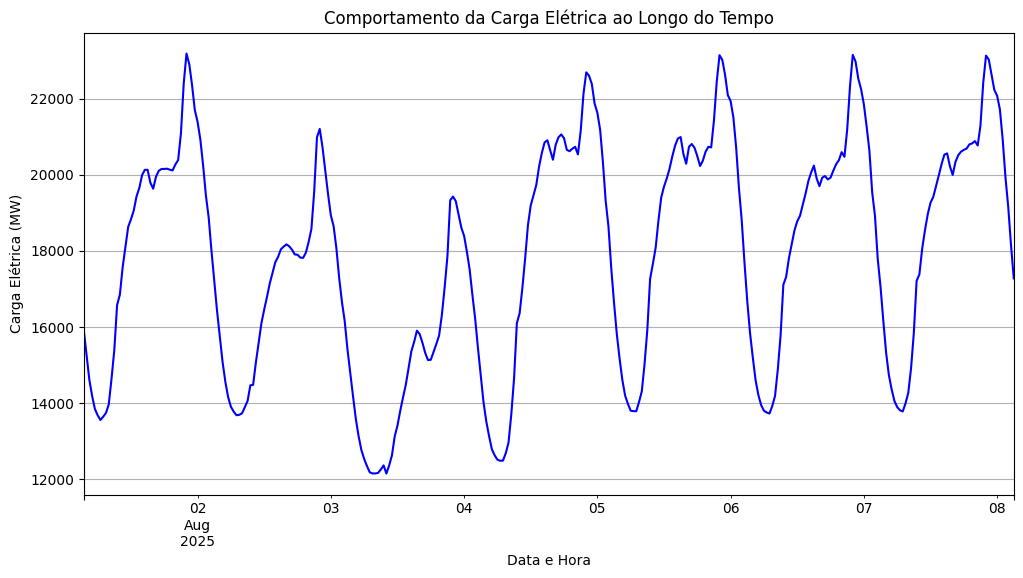

In [25]:
#1º Gráfico: Comportamento da carga ao longo do tempo
carga = df_carga.set_index("data_hora_utc")

plt.figure(figsize=(12, 6))
carga["carga_global_mw"].plot(color="blue")
plt.title("Comportamento da Carga Elétrica ao Longo do Tempo")
plt.xlabel("Data e Hora")
plt.ylabel("Carga Elétrica (MW)")
plt.grid(True)
plt.show()



# **Análise gráfico 1**

O gráfico nos mostra o crescimento do consumo de energia ao longo do tempo. Percebe-se que o consumo tende a crescer conforme o dia avança, tendo um crescimento mais acentuado no final do dia, com rápida queda na transição dos dias.

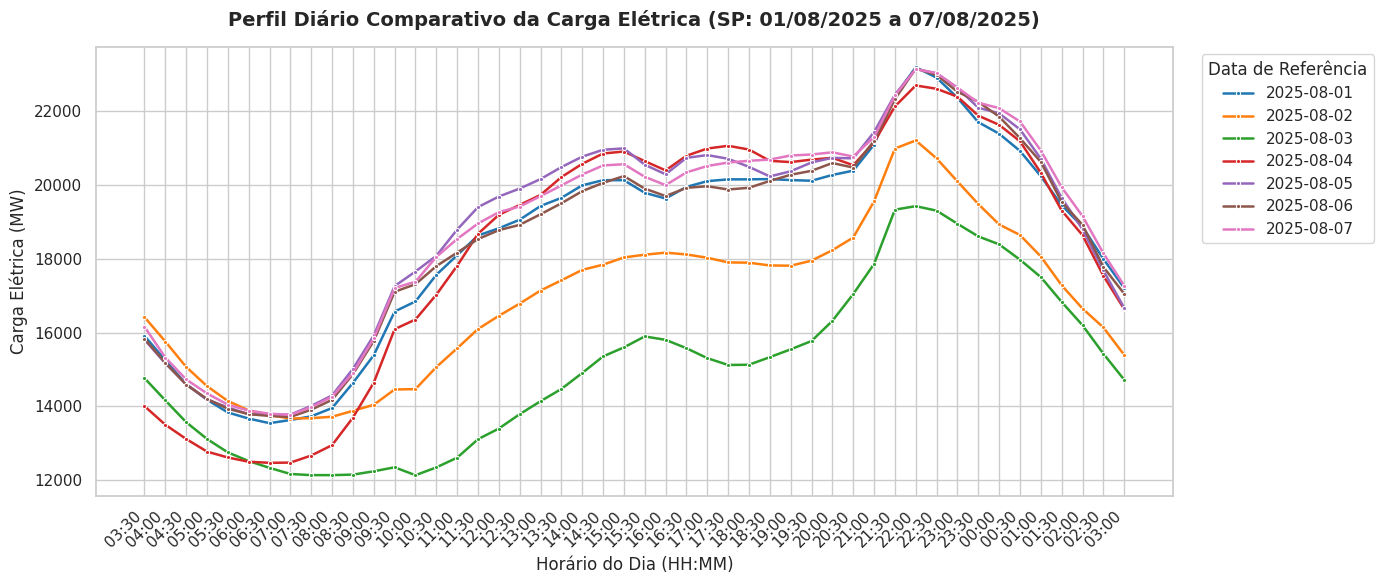

In [26]:
#2º Gráfico: Distribuição das cargas

df_carga["horario"] = df_carga["data_hora_utc"].dt.strftime("%H:%M")

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_carga,
    x="horario",
    y="carga_global_mw",
    hue="data_referencia",
    marker="o",
    markersize=3,
    linewidth=1.8,
    palette="tab10",
)

plt.title(
    "Perfil Diário Comparativo da Carga Elétrica (SP: 01/08/2025 a"
    " 07/08/2025)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Horário do Dia (HH:MM)")
plt.ylabel("Carga Elétrica (MW)")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Data de Referência",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

# **Análise gráfico 2**

O gráfico nos mostra o crescimento do consumo de energia conforme as horas, onde cada linha representa um dia diferente. As linhas referentes aos dias 2/8/2025 e 3/8/2025 dizem respeito a sábado e domingo respectivamente, com um consumo geral consideravelmente menor ao consumo durante a semana.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [27]:
# Informações gerais da análise
regiao_analisada = parametros["cod_areacarga"]
periodo_inicio = pd.to_datetime(parametros["dat_inicio"]).strftime("%d/%m/%Y")
periodo_fim = pd.to_datetime(parametros["dat_fim"]).strftime("%d/%m/%Y")

# Momento do maior pico registrado
momento_pico = pd.to_datetime(horario_pico).strftime("%d/%m/%Y %H:%M")

# Síntese dos resultados produzidos nos desafios anteriores
resumo_resultados = f"""
Região analisada: {regiao_analisada}
Período analisado: {periodo_inicio} a {periodo_fim}
Quantidade de registros: {quantidade_medicoes}

Carga mínima: {carga_minima:.2f} MW
Carga máxima: {carga_maxima:.2f} MW
Carga média: {carga_media:.2f} MW
Mediana: {mediana:.2f} MW

Limiar de alta demanda (90% da carga máxima): {limiar:.2f} MW
Registros de alta demanda: {registros}
Percentual de alta demanda: {percentual:.2f}%
Momento do pico: {momento_pico}
Valor do pico: {maior_valor:.2f} MW

Segundo critério analisado: carga acima da média ({media_carga:.2f} MW)
Registros acima da média: {registros_acima_media}
Percentual de registros acima da média: {percentual_acima_media:.2f}%

Comparação dos critérios:
- Alta demanda (> 90% do máximo): {registros_alta_demanda} registros
- Carga acima da média: {registros_acima_media} registros
- Registros presentes nos dois recortes: {interseccao}
"""

print(resumo_resultados)


Região analisada: SP
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336

Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW

Limiar de alta demanda (90% da carga máxima): 20866.78 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 01/08/2025 22:00
Valor do pico: 23185.31 MW

Segundo critério analisado: carga acima da média (17870.83 MW)
Registros acima da média: 184
Percentual de registros acima da média: 54.76%

Comparação dos critérios:
- Alta demanda (> 90% do máximo): 50 registros
- Carga acima da média: 184 registros
- Registros presentes nos dois recortes: 50



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [36]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [30]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [41]:
response_gemini = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA DO SETOR ELÉTRICO**

**1. Caracterização do Conjunto Analisado**
O conjunto de dados compreende a região de São Paulo (SP) para o período de 01/08/2025 a 07/08/2025. A base é composta por 336 registros de carga.

**2. Principais Indicadores**
*   **Carga Mínima:** 12.139,25 MW
*   **Carga Máxima:** 23.185,31 MW
*   **Carga Média:** 17.870,83 MW
*   **Mediana:** 18.199,13 MW
*   **Momento do Pico:** 01/08/2025 às 22:00 (com o valor de 23.185,31 MW)

**3. Análise dos Períodos de Alta Demanda**
O limiar de alta demanda foi definido em 90% da carga máxima, resultando no valor de 20.866,78 MW. 
*   **Resultados observados:** Foram contabilizados 50 registros acima deste limiar, o que representa 14,88% do total de registros do período.
*   **Hipóteses:** Não há dados suficientes para determinar a causa da concentração desses registros ou do pico ocorrido no dia 01/08 às 22:00, sendo necessária uma análise complementar com variáveis meteorológicas ou se

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

## DESAFIO 9 — Validação crítica

**1. Os indicadores foram utilizados corretamente?**
Sim, todos os indicadores calculados foram utilizados corretamente no relatório gerado pelo Gemini.

**2. Há alguma afirmação que não pode ser confirmada pelos dados?**
Não, todas as afirmações factuais podem ser confirmadas pelos dados e cálculos fornecidos.

**3. Houve interpretação exagerada ou causalidade não demonstrada?**
Não, o Gemini evitou interpretações exageradas, diferenciando claramente observações de hipóteses.

**4. Que alterações a equipe realizou no texto?**
A equipe revisou e inseriu o texto gerado pelo Gemini como a versão final do relatório, sem realizar modificações em seu conteúdo.

## Relatório final

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA DO SETOR ELÉTRICO**

**1. Caracterização do Conjunto Analisado**
O conjunto de dados compreende a região de São Paulo (SP) para o período de 01/08/2025 a 07/08/2025. A base é composta por 336 registros de carga.

**2. Principais Indicadores**
*   **Carga Mínima:** 12.139,25 MW
*   **Carga Máxima:** 23.185,31 MW
*   **Carga Média:** 17.870,83 MW
*   **Mediana:** 18.199,13 MW
*   **Momento do Pico:** 01/08/2025 às 22:00 (com o valor de 23.185,31 MW)

**3. Análise dos Períodos de Alta Demanda**
O limiar de alta demanda foi definido em 90% da carga máxima, resultando no valor de 20.866,78 MW.
*   **Resultados observados:** Foram contabilizados 50 registros acima deste limiar, o que representa 14,88% do total de registros do período.
*   **Hipóteses:** Não há dados suficientes para determinar a causa da concentração desses registros ou do pico ocorrido no dia 01/08 às 22:00, sendo necessária uma análise complementar com variáveis meteorológicas ou setoriais para validação de hipóteses causais.

**4. Comparação com o Segundo Critério**
O segundo critério analisou os registros com carga acima da média (17.870,83 MW).
*   **Resultados observados:** Identificou-se 184 registros acima da média, correspondendo a 54,76% do total.
*   **Comparação cruzada:** Todos os 50 registros que atingiram o critério de alta (> 90% do máximo) também estão contidos no grupo de registros acima da média. O segundo critério abrange uma quantidade 3,68 vezes maior de registros em comparação ao critério de alta demanda.

**5. Conclusão**
Os dados mostram que a carga na região de SP entre 01/08/2025 e 07/08/2025 oscilou entre 12.139,25 MW e 23.185,31 MW, com comportamento assimétrico concentrando a maioria dos registros (54,76%) acima da média. O regime de alta demanda (> 90% do pico) é um evento restrito, ocorrendo em menos de 15% do tempo analisado, sendo integralmente englobado pelo conjunto de cargas superiores à média.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**